# Przykladowa analiza danych w pandas
Notebook analizuje zbior z brakami i zapisuje wyniki do katalogu analysis_output.

In [11]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path.cwd()
data_path = project_root / 'data' / 'loan_data_with_missing.csv'
output_dir = project_root / 'analysis_output'
output_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

Rows: 45000, Columns: 14


In [4]:
print('=== MISSING VALUES ===')
missing_count = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)
missing_table = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent.round(2),
})
missing_table

=== MISSING VALUES ===


,missing_count,missing_percent
person_age,4500,10.0
person_gender,4500,10.0
person_education,4500,10.0
person_income,4500,10.0
person_emp_exp,4500,10.0
person_home_ownership,4500,10.0
loan_amnt,4500,10.0
loan_intent,4500,10.0
loan_int_rate,4500,10.0
loan_percent_income,4500,10.0


In [5]:
print('=== DESCRIPTIVE STATS (NUMERIC) ===')
numeric_stats = df.describe(include=['number']).T
numeric_stats

=== DESCRIPTIVE STATS (NUMERIC) ===


,count,mean,std,min,25%,50%,75%,max
person_age,40500.0,27.760494,6.039723,20.00,24.00,26.00,30.00,144.00
person_income,40500.0,80283.078247,82153.324720,8000.00,47222.00,67024.50,95683.25,7200766.00
person_emp_exp,40500.0,5.400642,6.034116,0.00,1.00,4.00,8.00,125.00
loan_amnt,40500.0,9589.577630,6317.831708,500.00,5000.00,8000.00,12239.00,35000.00
loan_int_rate,40500.0,11.005218,2.976350,5.42,8.59,11.01,12.99,20.00
loan_percent_income,40500.0,0.139730,0.087301,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,40500.0,5.867605,3.882386,2.00,3.00,4.00,8.00,30.00
credit_score,40500.0,632.535407,50.459396,419.00,601.00,640.00,670.00,807.00
loan_status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


In [6]:
print('=== TARGET VARIABLE ANALYSIS: loan_status ===')
if 'loan_status' in df.columns:
    target_dist = df['loan_status'].value_counts(dropna=False)
    target_ratio = df['loan_status'].value_counts(normalize=True, dropna=False) * 100
    target_table = pd.DataFrame({
        'count': target_dist,
        'percent': target_ratio.round(2),
    })
else:
    target_table = pd.DataFrame()
target_table

=== TARGET VARIABLE ANALYSIS: loan_status ===


,count,percent
loan_status,,
0,35000,77.78
1,10000,22.22


In [7]:
print('=== RELATION TO TARGET (NUMERIC FEATURES) ===')
if 'loan_status' in df.columns:
    corr_series = (
        df.select_dtypes(include=['number'])
        .corr(numeric_only=True)['loan_status']
        .drop(labels=['loan_status'], errors='ignore')
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )
    corr_table = corr_series.to_frame(name='correlation_with_loan_status')
else:
    corr_table = pd.DataFrame()
corr_table

=== RELATION TO TARGET (NUMERIC FEATURES) ===


,correlation_with_loan_status
loan_percent_income,0.384242
loan_int_rate,0.331935
person_income,-0.132923
loan_amnt,0.109571
person_emp_exp,-0.021315
person_age,-0.020141
cb_person_cred_hist_length,-0.016251
credit_score,-0.008088


In [8]:
print('=== CATEGORICAL INSIGHT: loan_intent vs loan_status ===')
if {'loan_intent', 'loan_status'}.issubset(df.columns):
    intent_vs_status = pd.crosstab(
        df['loan_intent'],
        df['loan_status'],
        normalize='index',
        dropna=False
    ).round(3)
else:
    intent_vs_status = pd.DataFrame()
intent_vs_status

=== CATEGORICAL INSIGHT: loan_intent vs loan_status ===


loan_status,0,1
loan_intent,,
DEBTCONSOLIDATION,0.699,0.301
EDUCATION,0.832,0.168
HOMEIMPROVEMENT,0.738,0.262
MEDICAL,0.722,0.278
PERSONAL,0.800,0.200
VENTURE,0.857,0.143
NaN,0.764,0.236


In [9]:
missing_table.to_csv(output_dir / 'missing_values.csv')
numeric_stats.to_csv(output_dir / 'descriptive_stats_numeric.csv')
if not target_table.empty:
    target_table.to_csv(output_dir / 'loan_status_distribution.csv')
if not corr_table.empty:
    corr_table.to_csv(output_dir / 'numeric_correlation_with_loan_status.csv')
if not intent_vs_status.empty:
    intent_vs_status.to_csv(output_dir / 'loan_intent_vs_loan_status_share.csv')

summary_text = [
    'Pandas EDA summary',
    f'Rows: {df.shape[0]}',
    f'Columns: {df.shape[1]}',
    '',
    'Top missing columns (count):',
] + [f'- {idx}: {int(val)}' for idx, val in missing_count.head(5).items()]

(output_dir / 'summary.txt').write_text('\n'.join(summary_text), encoding='utf-8')
print(f'Saved analysis files to: {output_dir}')

Saved analysis files to: e:\studia pk II sem\zmum\advanced-ml-main\analysis_output


## Pairplot + korelacje (Pearson/Spearman)
Przy duzej liczbie rekordow pairplot moze byc nieczytelny, dlatego rysujemy go na probce.
Dodatkowo liczymy macierze korelacji Pearsona i Spearmana dla cech numerycznych.

Columns used: ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'credit_score', 'loan_status']
Rows used for plot/correlation: 1500

=== Pearson correlation ===


,person_age,person_income,loan_amnt,loan_int_rate,loan_percent_income,credit_score,loan_status
person_age,1.000,0.157,0.081,0.091,-0.038,0.156,-0.017
person_income,0.157,1.000,0.292,0.031,-0.291,0.012,-0.162
loan_amnt,0.081,0.292,1.000,0.141,0.593,0.008,0.152
loan_int_rate,0.091,0.031,0.141,1.000,0.094,0.002,0.310
loan_percent_income,-0.038,-0.291,0.593,0.094,1.000,0.002,0.409
credit_score,0.156,0.012,0.008,0.002,0.002,1.000,-0.020
loan_status,-0.017,-0.162,0.152,0.310,0.409,-0.020,1.000



=== Spearman correlation ===


,person_age,person_income,loan_amnt,loan_int_rate,loan_percent_income,credit_score,loan_status
person_age,1.000,0.166,0.107,0.095,-0.034,0.143,-0.008
person_income,0.166,1.000,0.384,0.015,-0.359,0.010,-0.235
loan_amnt,0.107,0.384,1.000,0.113,0.679,0.003,0.135
loan_int_rate,0.095,0.015,0.113,1.000,0.100,0.000,0.295
loan_percent_income,-0.034,-0.359,0.679,0.100,1.000,-0.010,0.354
credit_score,0.143,0.010,0.003,0.000,-0.010,1.000,-0.020
loan_status,-0.008,-0.235,0.135,0.295,0.354,-0.020,1.000


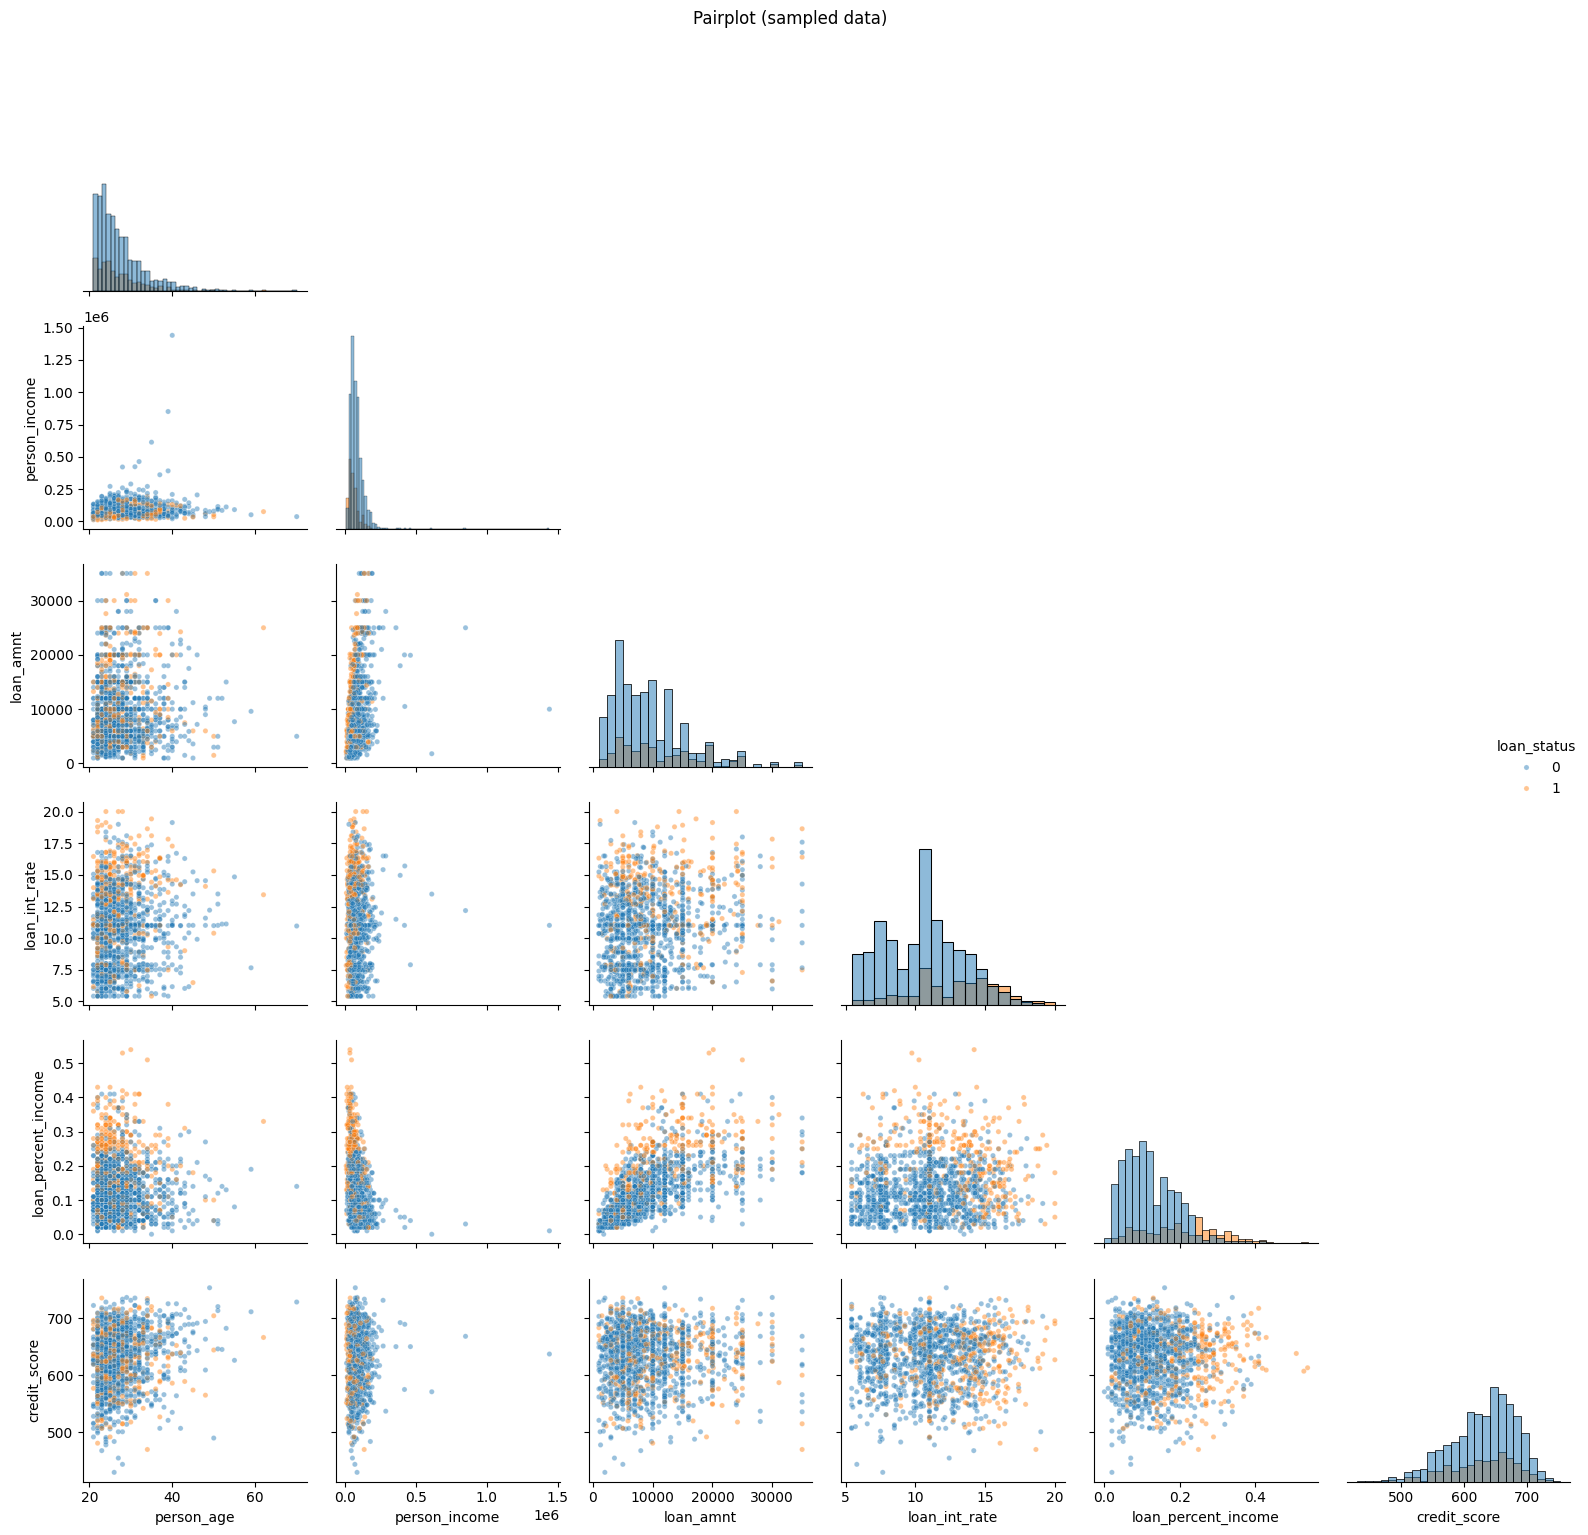

Pairplot saved to: e:\studia pk II sem\zmum\advanced-ml-main\analysis_output\pairplot_sample.png


In [14]:
preferred_cols = [
    'person_age',
    'person_income',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'credit_score',
    'loan_status',
]

numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
selected_cols = [c for c in preferred_cols if c in numeric_cols]
if len(selected_cols) < 3:
    selected_cols = numeric_cols[: min(7, len(numeric_cols))]

analysis_df = df[selected_cols].dropna()
max_points = 1500
if len(analysis_df) > max_points:
    analysis_df = analysis_df.sample(max_points, random_state=42)

print(f'Columns used: {selected_cols}')
print(f'Rows used for plot/correlation: {len(analysis_df)}')

pearson_corr = analysis_df.corr(method='pearson', numeric_only=True)
spearman_corr = analysis_df.corr(method='spearman', numeric_only=True)

print('\n=== Pearson correlation ===')
display(pearson_corr.round(3))

print('\n=== Spearman correlation ===')
display(spearman_corr.round(3))

pearson_corr.to_csv(output_dir / 'pearson_correlation.csv')
spearman_corr.to_csv(output_dir / 'spearman_correlation.csv')

plot_df = analysis_df.copy()
hue_col = None
if 'loan_status' in plot_df.columns:
    plot_df['loan_status'] = plot_df['loan_status'].astype('Int64').astype(str)
    hue_col = 'loan_status'

g = sns.pairplot(
    plot_df,
    hue=hue_col,
    diag_kind='hist',
    corner=True,
    plot_kws={'alpha': 0.45, 's': 14},
)
g.fig.suptitle('Pairplot (sampled data)', y=1.02)
g.fig.tight_layout()

pairplot_path = output_dir / 'pairplot_sample.png'
g.savefig(pairplot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Pairplot saved to: {pairplot_path}')